# VinDatathon 2026 — Feature Engineering Evidence Notebook

Notebook này dùng cho **report cuối**: mục tiêu không phải train model, mà là chứng minh bằng EDA tại sao các feature engineering trong forecasting pipeline là hợp lý.

Cấu trúc:
1. Load dữ liệu và tạo helper plot.
2. Liệt kê toàn bộ nhóm feature engineering đang dùng trong model.
3. Với mỗi nhóm feature: vẽ biểu đồ tương ứng, đưa nhận xét ngắn, và chỉ rõ feature nào được sinh ra.
4. Kết luận feature nào dùng cho Revenue, feature nào hợp hơn cho COGS / margin ratio.


In [1]:
# =========================================================
# 0. Imports & display config
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = Path('/content/drive/MyDrive/datathon-2026-round-1')
    OUT_DIR  = Path('/content/drive/MyDrive/VinDatathon/outputs')
except Exception:
    # Chỉnh lại path này nếu chạy local/Kaggle.
    DATA_DIR = Path('/content/drive/MyDrive/datathon-2026-round-1')
    OUT_DIR  = Path('./outputs')

OUT_DIR.mkdir(parents=True, exist_ok=True)
print('DATA_DIR =', DATA_DIR)
print('OUT_DIR  =', OUT_DIR)


Mounted at /content/drive
DATA_DIR = /content/drive/MyDrive/datathon-2026-round-1
OUT_DIR  = /content/drive/MyDrive/VinDatathon/outputs


In [3]:
# =========================================================
# 1. Load core tables
# =========================================================
def safe_read_csv(name, parse_dates=None):
    path = DATA_DIR / name
    if not path.exists():
        print(f'[WARN] Missing {name}')
        return None
    df = pd.read_csv(path, parse_dates=parse_dates)
    print(f'[OK] {name}:', df.shape)
    return df

sales = safe_read_csv('sales.csv', parse_dates=['Date'])
assert sales is not None, 'sales.csv is required'

sales = sales.sort_values('Date').reset_index(drop=True)
sales['year'] = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month
sales['day'] = sales['Date'].dt.day
sales['dow'] = sales['Date'].dt.dayofweek
sales['doy'] = sales['Date'].dt.dayofyear
sales['quarter'] = sales['Date'].dt.quarter
sales['days_to_eom'] = sales['Date'].dt.days_in_month - sales['day']
sales['days_from_som'] = sales['day'] - 1
sales['cost_ratio'] = sales['COGS'] / sales['Revenue']
sales['margin_gap'] = sales['Revenue'] - sales['COGS']

display(sales.head())
display(sales[['Revenue','COGS','cost_ratio','margin_gap']].describe())


[OK] sales.csv: (3833, 3)


,Date,Revenue,COGS,year,month,day,dow,doy,quarter,days_to_eom,days_from_som,cost_ratio,margin_gap
0,2012-07-04,5123547.94,3982991.19,2012,7,4,2,186,3,27,3,0.777389,1140556.75
1,2012-07-05,2751773.45,2150580.23,2012,7,5,3,187,3,26,4,0.781525,601193.22
2,2012-07-06,3054029.42,2517632.84,2012,7,6,4,188,3,25,5,0.824364,536396.58
3,2012-07-07,2667930.94,2108246.62,2012,7,7,5,189,3,24,6,0.790218,559684.32
4,2012-07-08,2360851.90,1808622.79,2012,7,8,6,190,3,23,7,0.766089,552229.11


,Revenue,COGS,cost_ratio,margin_gap
count,3.833000e+03,3.833000e+03,3833.000000,3.833000e+03
mean,4.286584e+06,3.695134e+06,0.874607,5.914495e+05
std,2.624840e+06,2.219789e+06,0.127356,6.661960e+05
min,2.798139e+05,2.365763e+05,0.713084,-2.567312e+06
25%,2.471089e+06,2.150580e+06,0.797113,2.292740e+05
50%,3.647304e+06,3.161113e+06,0.821700,5.445544e+05
75%,5.350877e+06,4.637294e+06,0.917387,8.760810e+05
max,2.090527e+07,1.653586e+07,1.574580,4.369414e+06


## 2. Feature engineering đang có trong notebook model

Bảng dưới đây là inventory các nhóm feature chính. Mỗi nhóm sẽ được kiểm tra bằng EDA ở các section sau.


In [4]:
# =========================================================
# 2. Feature engineering inventory
# =========================================================
feature_inventory = pd.DataFrame([
    {
        'group': 'Basic calendar',
        'features': 'year, month, day, dow, doy, quarter, is_weekend, dim',
        'hypothesis': 'Doanh thu/COGS có seasonal pattern theo tháng, thứ trong tuần, quý và cuối tuần.',
        'evidence_section': '3.1, 3.2'
    },
    {
        'group': 'Month boundary',
        'features': 'is_first1/2/3, is_last1/2/3, days_from_som, days_to_eom',
        'hypothesis': 'Đầu/cuối tháng có thể xuất hiện hiệu ứng lương, chốt KPI, campaign hoặc hành vi mua sắm khác ngày giữa tháng.',
        'evidence_section': '3.3'
    },
    {
        'group': 'Trend & regime',
        'features': 't_days, t_years, t_years2, regime_pre2019, regime_2019, regime_post2019, regime_post2022',
        'hypothesis': 'Series có shift mạnh quanh 2019/Covid và giai đoạn gần 2022; cần feature cho level/trend thay đổi.',
        'evidence_section': '3.4'
    },
    {
        'group': 'Fourier seasonality',
        'features': 'sin_y{k}, cos_y{k}, sin_w{k}, cos_w{k}, sin_m{k}, cos_m{k}',
        'hypothesis': 'Seasonality lặp lại mượt theo năm/tuần/tháng; Fourier encode chu kỳ tốt hơn one-hot rời rạc.',
        'evidence_section': '3.5'
    },
    {
        'group': 'Fixed holidays',
        'features': 'hol_new_year, hol_womens_day, hol_reunification, hol_labor_day, hol_national_day, hol_1111, hol_1212, Christmas...',
        'hypothesis': 'Ngày lễ / ngày sale cố định có demand khác baseline gần đó.',
        'evidence_section': '3.6'
    },
    {
        'group': 'Tet distance',
        'features': 'tet_days_diff, tet_abs_diff, tet_in_7/14, tet_before_7, tet_after_7, tet_on',
        'hypothesis': 'Tết thay đổi ngày theo năm nên không thể dùng fixed month-day; cần distance-to-Tet.',
        'evidence_section': '3.7'
    },
    {
        'group': 'Promo windows',
        'features': 'promo_* flags, promo_*_since, promo_*_until, promo_*_disc, promo_any',
        'hypothesis': 'Các campaign có window dài; hiệu ứng có thể phụ thuộc ngày thứ mấy trong campaign và discount level.',
        'evidence_section': '3.8'
    },
    {
        'group': 'August odd/even regime',
        'features': 'is_odd_year, is_even_year, is_august, august_odd/even, august_last_week_even/odd, august_*_x_t',
        'hypothesis': 'EDA cho thấy tháng 8 tách rất rõ theo odd/even year; đặc biệt last-week August even có spike, odd August giống discount-suppression regime.',
        'evidence_section': '3.9'
    },
    {
        'group': 'Auxiliary historical priors',
        'features': 'exp_web_*_month, exp_aux_discount_*_month, exp_aux_units_sold_month, aux_inv_*',
        'hypothesis': 'Không có future raw values, nên dùng historical expectation theo month/month×dow làm prior an toàn.',
        'evidence_section': '4'
    },
    {
        'group': 'Auxiliary interactions',
        'features': 'exp_sessions_x_first3/last3/weekend, exp_discount_x_august_odd/even/post2019, inv_*_x_post2019/august/last3',
        'hypothesis': 'Tín hiệu business chỉ mạnh trong một context: ví dụ traffic × cuối tháng, discount × August odd, inventory × post2019.',
        'evidence_section': '4.4'
    },
])
display(feature_inventory)


,group,features,hypothesis,evidence_section
0,Basic calendar,"year, month, day, dow, doy, quarter, is_weeken...","Doanh thu/COGS có seasonal pattern theo tháng,...","3.1, 3.2"
1,Month boundary,"is_first1/2/3, is_last1/2/3, days_from_som, da...",Đầu/cuối tháng có thể xuất hiện hiệu ứng lương...,3.3
2,Trend & regime,"t_days, t_years, t_years2, regime_pre2019, reg...",Series có shift mạnh quanh 2019/Covid và giai ...,3.4
3,Fourier seasonality,"sin_y{k}, cos_y{k}, sin_w{k}, cos_w{k}, sin_m{...",Seasonality lặp lại mượt theo năm/tuần/tháng; ...,3.5
4,Fixed holidays,"hol_new_year, hol_womens_day, hol_reunificatio...",Ngày lễ / ngày sale cố định có demand khác bas...,3.6
5,Tet distance,"tet_days_diff, tet_abs_diff, tet_in_7/14, tet_...",Tết thay đổi ngày theo năm nên không thể dùng ...,3.7
6,Promo windows,"promo_* flags, promo_*_since, promo_*_until, p...",Các campaign có window dài; hiệu ứng có thể ph...,3.8
7,August odd/even regime,"is_odd_year, is_even_year, is_august, august_o...",EDA cho thấy tháng 8 tách rất rõ theo odd/even...,3.9
8,Auxiliary historical priors,"exp_web_*_month, exp_aux_discount_*_month, exp...","Không có future raw values, nên dùng historica...",4
9,Auxiliary interactions,"exp_sessions_x_first3/last3/weekend, exp_disco...",Tín hiệu business chỉ mạnh trong một context: ...,4.4


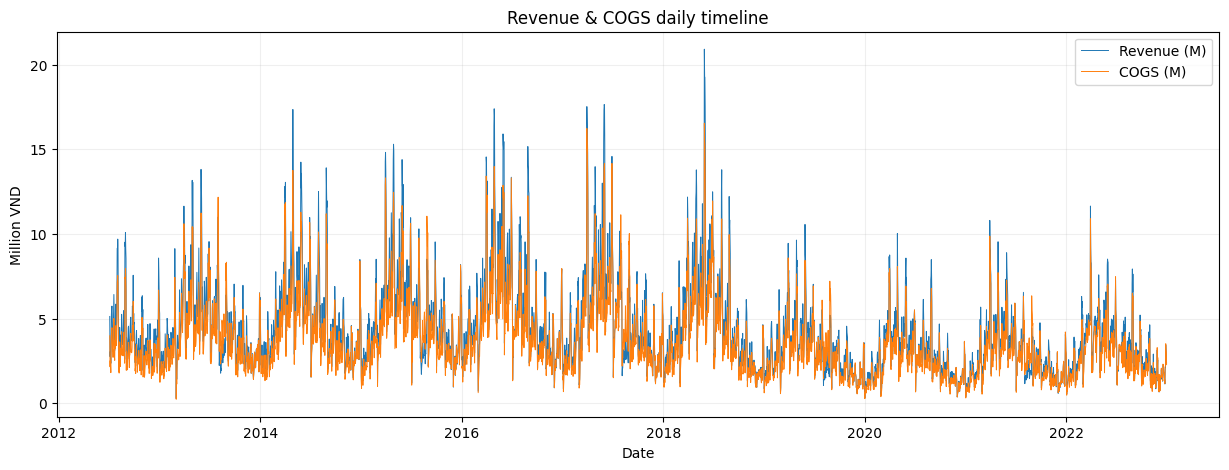

In [5]:
# =========================================================
# 3. Helper functions for plots / tables
# =========================================================
def add_value_labels(ax, fmt='{:.2f}'):
    for p in ax.patches:
        h = p.get_height()
        if np.isfinite(h):
            ax.annotate(fmt.format(h), (p.get_x()+p.get_width()/2, h), ha='center', va='bottom', fontsize=8, rotation=0)

def plot_daily_series(df, cols=('Revenue','COGS'), title='Daily series'):
    plt.figure(figsize=(15, 5))
    for col in cols:
        plt.plot(df['Date'], df[col] / 1e6, lw=0.7, label=f'{col} (M)')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Million VND')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

def plot_group_mean(df, group_col, target='Revenue', title=None, order=None, scale=1e6):
    tmp = df.groupby(group_col, dropna=False)[target].mean().reset_index()
    if order is not None:
        tmp[group_col] = pd.Categorical(tmp[group_col], categories=order, ordered=True)
        tmp = tmp.sort_values(group_col)
    plt.figure(figsize=(10, 4))
    plt.bar(tmp[group_col].astype(str), tmp[target] / scale)
    plt.title(title or f'Mean {target} by {group_col}')
    plt.xlabel(group_col)
    plt.ylabel(f'Mean {target} / {scale:g}')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.2)
    plt.show()
    display(tmp)
    return tmp

plot_daily_series(sales, title='Revenue & COGS daily timeline')


## 3. Calendar/time-based evidence

### 3.1 Monthly seasonality → `month`, yearly Fourier, promo/holiday context

Nếu các đường theo tháng lặp lại tương đối ổn định qua năm, model nên có `month`, yearly Fourier và các interaction theo tháng.


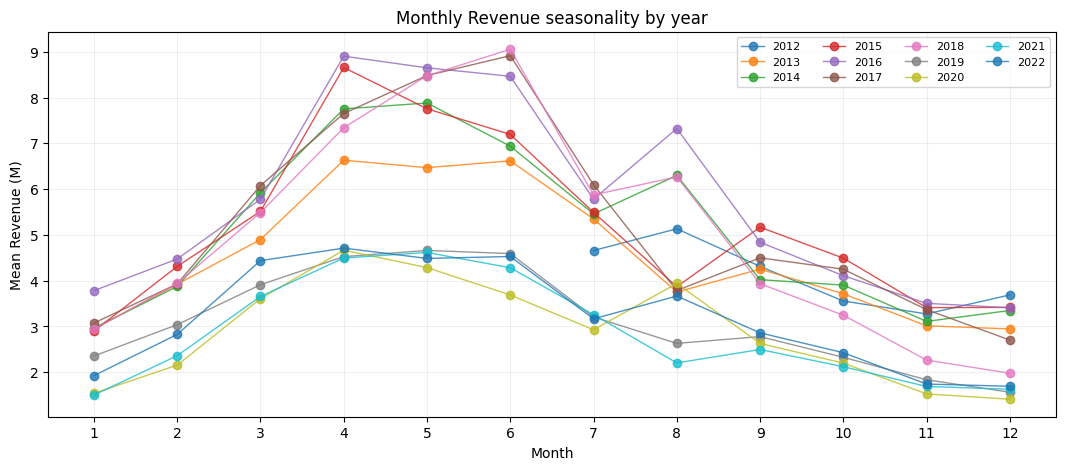

In [7]:
monthly = sales.groupby(['year','month'], as_index=False).agg(
    Revenue=('Revenue','mean'),
    COGS=('COGS','mean'),
    cost_ratio=('cost_ratio','mean')
)

plt.figure(figsize=(13, 5))
for y in sorted(monthly['year'].unique()):
    d = monthly[monthly['year'] == y]
    plt.plot(d['month'], d['Revenue']/1e6, marker='o', lw=1, alpha=0.8, label=str(y))
plt.title('Monthly Revenue seasonality by year')
plt.xlabel('Month')
plt.ylabel('Mean Revenue (M)')
plt.xticks(range(1, 13))
plt.grid(alpha=0.2)
plt.legend(ncol=4, fontsize=8)
plt.show()


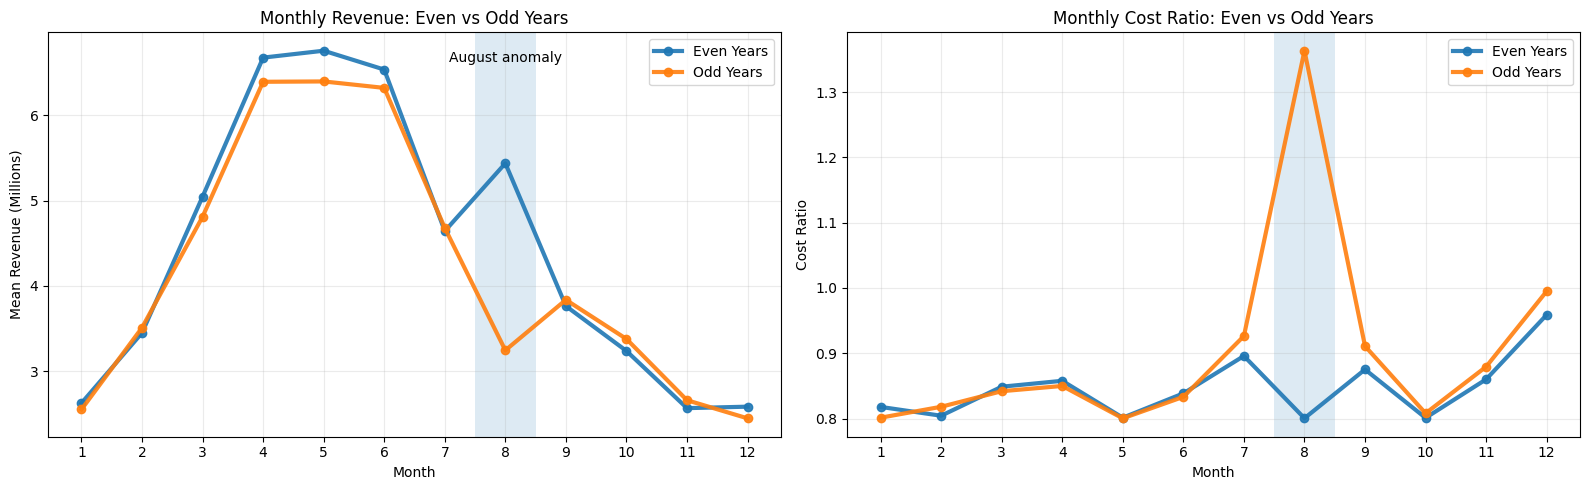

FEATURE ENGINEERING INSIGHT
August Revenue difference (Odd vs Even years): -40.29%

Possible feature engineering:
- is_odd_year
- is_even_year
- august_odd_year_interaction
- august_even_year_interaction

Motivation:
Seasonality pattern is not identical between even and odd years.
August especially shows different business behavior depending on year parity.



In [8]:
# =========================================================
# EVEN YEAR vs ODD YEAR MONTHLY SEASONALITY
# =========================================================

monthly_even_odd = (
    sales
    .assign(year_type=np.where(sales['year'] % 2 == 0, 'Even Years', 'Odd Years'))
    .groupby(['year_type', 'month'], as_index=False)
    .agg(
        Revenue=('Revenue', 'mean'),
        COGS=('COGS', 'mean'),
        cost_ratio=('cost_ratio', 'mean')
    )
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ---------------------------------------------------------
# Revenue
# ---------------------------------------------------------
for t in ['Even Years', 'Odd Years']:
    d = monthly_even_odd[monthly_even_odd['year_type'] == t]

    axes[0].plot(
        d['month'],
        d['Revenue'] / 1e6,
        marker='o',
        linewidth=3,
        alpha=0.9,
        label=t
    )

axes[0].set_title('Monthly Revenue: Even vs Odd Years')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Mean Revenue (Millions)')
axes[0].set_xticks(range(1, 13))
axes[0].grid(alpha=0.25)
axes[0].legend()

# highlight August
axes[0].axvspan(7.5, 8.5, alpha=0.15)
axes[0].text(8, axes[0].get_ylim()[1]*0.95,
             'August anomaly',
             ha='center',
             fontsize=10)

# ---------------------------------------------------------
# Cost Ratio
# ---------------------------------------------------------
for t in ['Even Years', 'Odd Years']:
    d = monthly_even_odd[monthly_even_odd['year_type'] == t]

    axes[1].plot(
        d['month'],
        d['cost_ratio'],
        marker='o',
        linewidth=3,
        alpha=0.9,
        label=t
    )

axes[1].set_title('Monthly Cost Ratio: Even vs Odd Years')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Cost Ratio')
axes[1].set_xticks(range(1, 13))
axes[1].grid(alpha=0.25)
axes[1].legend()

axes[1].axvspan(7.5, 8.5, alpha=0.15)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# QUICK INSIGHT FOR REPORT
# ---------------------------------------------------------

print("=" * 60)
print("FEATURE ENGINEERING INSIGHT")
print("=" * 60)

aug_even = monthly_even_odd[
    (monthly_even_odd['year_type'] == 'Even Years') &
    (monthly_even_odd['month'] == 8)
]['Revenue'].values[0]

aug_odd = monthly_even_odd[
    (monthly_even_odd['year_type'] == 'Odd Years') &
    (monthly_even_odd['month'] == 8)
]['Revenue'].values[0]

diff_pct = ((aug_odd - aug_even) / aug_even) * 100

print(f"August Revenue difference (Odd vs Even years): {diff_pct:.2f}%")

print("""
Possible feature engineering:
- is_odd_year
- is_even_year
- august_odd_year_interaction
- august_even_year_interaction

Motivation:
Seasonality pattern is not identical between even and odd years.
August especially shows different business behavior depending on year parity.
""")

**Report note:** Revenue có pattern theo tháng và level khác nhau theo năm. Vì vậy model dùng cả `month`/`quarter` và Fourier yearly để học seasonal shape, đồng thời dùng trend/regime để xử lý level shift giữa các năm.


### 3.2 Weekday/weekend seasonality → `dow`, `is_weekend`, weekly Fourier


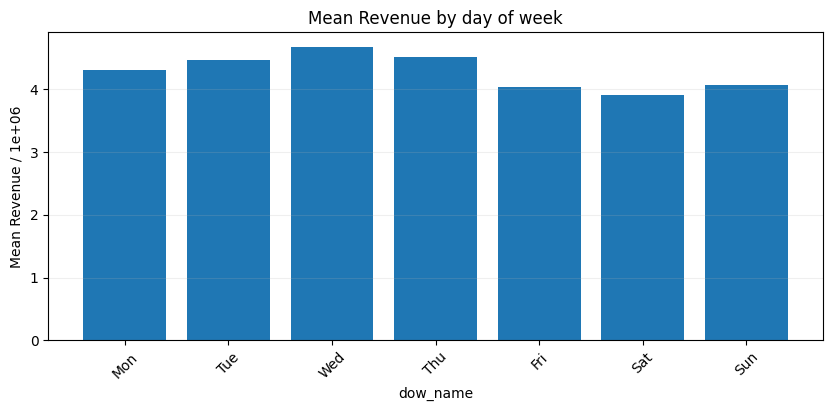

,dow_name,Revenue
1,Mon,4.311035e+06
5,Tue,4.465103e+06
6,Wed,4.680065e+06
4,Thu,4.523044e+06
0,Fri,4.046390e+06
2,Sat,3.906581e+06
3,Sun,4.073854e+06


,dow_name,Revenue
1,Mon,4.311035e+06
5,Tue,4.465103e+06
6,Wed,4.680065e+06
4,Thu,4.523044e+06
0,Fri,4.046390e+06
2,Sat,3.906581e+06
3,Sun,4.073854e+06


In [12]:
dow_map = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
sales['dow_name'] = sales['dow'].map(dow_map)
plot_group_mean(sales, 'dow_name', target='Revenue', title='Mean Revenue by day of week', order=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])


**Report note:** Nếu weekday/weekend có mean khác nhau, `dow`, `is_weekend`, `sin_w*`, `cos_w*` giúp model encode chu kỳ 7 ngày mà không cần dùng lag recursive.


### 3.3 Đầu/cuối tháng → `is_first1/2/3`, `is_last1/2/3`, `days_from_som`, `days_to_eom`


,month_pos_bucket,n_days,mean_revenue,median_revenue,mean_cogs,mean_cost_ratio,rev_vs_middle_%
0,first_3_days,375,5.120412e+06,4073777.92,4.485549e+06,0.879742,32.467666
1,last_3_days,378,6.891200e+06,6104530.53,6.048942e+06,0.889466,78.278835
2,middle_days,3080,3.865405e+06,3448665.22,3.310023e+06,0.872158,0.000000


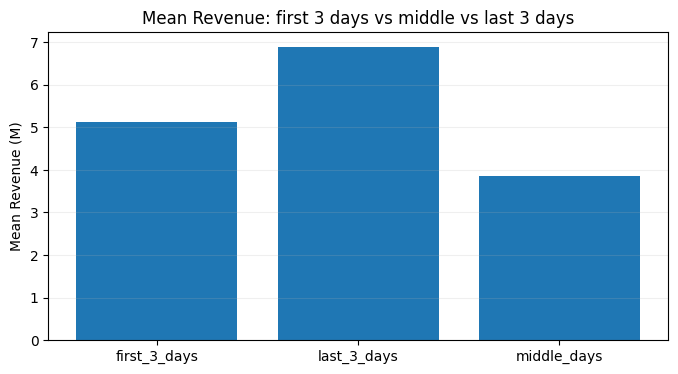

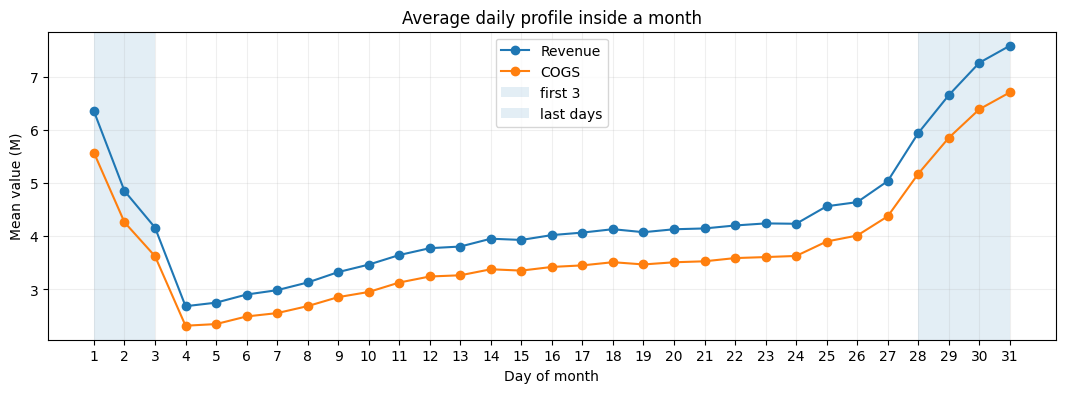

In [13]:
# Create month-boundary flags
for k in [1, 2, 3]:
    sales[f'is_first{k}'] = (sales['days_from_som'] <= k - 1).astype(int)
    sales[f'is_last{k}']  = (sales['days_to_eom'] <= k - 1).astype(int)

sales['month_pos_bucket'] = np.select(
    [sales['is_first3'].eq(1), sales['is_last3'].eq(1)],
    ['first_3_days', 'last_3_days'],
    default='middle_days'
)

boundary = sales.groupby('month_pos_bucket', as_index=False).agg(
    n_days=('Date','count'),
    mean_revenue=('Revenue','mean'),
    median_revenue=('Revenue','median'),
    mean_cogs=('COGS','mean'),
    mean_cost_ratio=('cost_ratio','mean'),
)
boundary['rev_vs_middle_%'] = 100 * (boundary['mean_revenue'] / boundary.loc[boundary['month_pos_bucket']=='middle_days','mean_revenue'].iloc[0] - 1)
display(boundary)

plt.figure(figsize=(8,4))
plt.bar(boundary['month_pos_bucket'], boundary['mean_revenue']/1e6)
plt.title('Mean Revenue: first 3 days vs middle vs last 3 days')
plt.ylabel('Mean Revenue (M)')
plt.grid(axis='y', alpha=0.2)
plt.show()

# More detailed: average revenue by day within month, clipped to 31 days.
day_profile = sales.groupby('day', as_index=False).agg(Revenue=('Revenue','mean'), COGS=('COGS','mean'))
plt.figure(figsize=(13,4))
plt.plot(day_profile['day'], day_profile['Revenue']/1e6, marker='o', label='Revenue')
plt.plot(day_profile['day'], day_profile['COGS']/1e6, marker='o', label='COGS')
plt.axvspan(1, 3, alpha=0.12, label='first 3')
plt.axvspan(28, 31, alpha=0.12, label='last days')
plt.title('Average daily profile inside a month')
plt.xlabel('Day of month')
plt.ylabel('Mean value (M)')
plt.xticks(range(1, 32))
plt.grid(alpha=0.2)
plt.legend()
plt.show()


### 3.4 Trend / regime shift → `t_years`, `t_years2`, `regime_pre2019`, `regime_2019`, `regime_post2019`, `regime_post2022`


,year,Revenue,COGS,cost_ratio,n_days
0,2012,4.096673e+06,3.245646e+06,0.792902,181
1,2013,4.540190e+06,4.016384e+06,0.896240,365
2,2014,5.128345e+06,4.313993e+06,0.846276,365
3,2015,5.177901e+06,4.562854e+06,0.898979,365
4,2016,5.750384e+06,4.864916e+06,0.854314,366
5,2017,5.236067e+06,4.642153e+06,0.903318,365
6,2018,5.068829e+06,4.225139e+06,0.842787,365
7,2019,3.114524e+06,2.753981e+06,0.897562,365
8,2020,2.881181e+06,2.420998e+06,0.847295,366
9,2021,2.857643e+06,2.578439e+06,0.920843,365


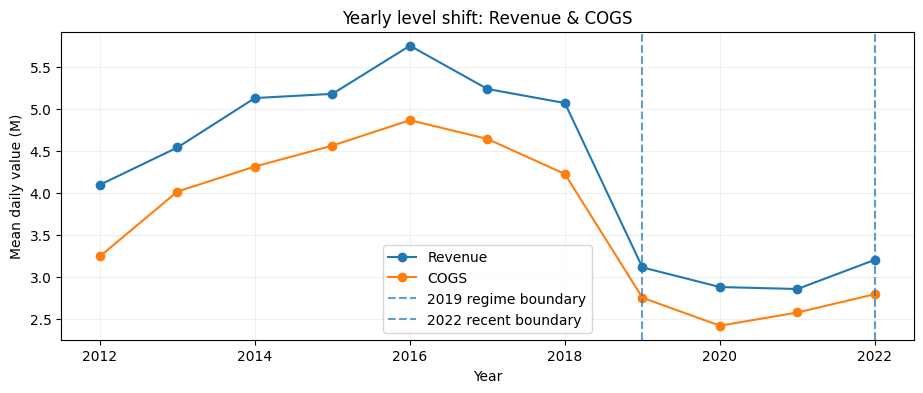

,regime,Revenue,COGS,cost_ratio,n_days
0,2020_2021,2.869428e+06,2.499610e+06,0.884019,731
1,post2022,3.204791e+06,2.795672e+06,0.879103,365
2,pre2019,5.070141e+06,4.346801e+06,0.867482,2372
3,year2019,3.114524e+06,2.753981e+06,0.897562,365


In [14]:
yearly = sales.groupby('year', as_index=False).agg(
    Revenue=('Revenue','mean'),
    COGS=('COGS','mean'),
    cost_ratio=('cost_ratio','mean'),
    n_days=('Date','count')
)

display(yearly)

plt.figure(figsize=(11,4))
plt.plot(yearly['year'], yearly['Revenue']/1e6, marker='o', label='Revenue')
plt.plot(yearly['year'], yearly['COGS']/1e6, marker='o', label='COGS')
plt.axvline(2019, ls='--', alpha=0.7, label='2019 regime boundary')
plt.axvline(2022, ls='--', alpha=0.7, label='2022 recent boundary')
plt.title('Yearly level shift: Revenue & COGS')
plt.xlabel('Year')
plt.ylabel('Mean daily value (M)')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

sales['regime'] = np.select(
    [sales['year'] <= 2018, sales['year'].eq(2019), sales['year'].between(2020, 2021), sales['year'] >= 2022],
    ['pre2019', 'year2019', '2020_2021', 'post2022'],
    default='other'
)
regime_summary = sales.groupby('regime', as_index=False).agg(
    Revenue=('Revenue','mean'), COGS=('COGS','mean'), cost_ratio=('cost_ratio','mean'), n_days=('Date','count')
)
display(regime_summary)


### 3.5 Fourier seasonality → encode chu kỳ mượt theo năm/tuần/tháng


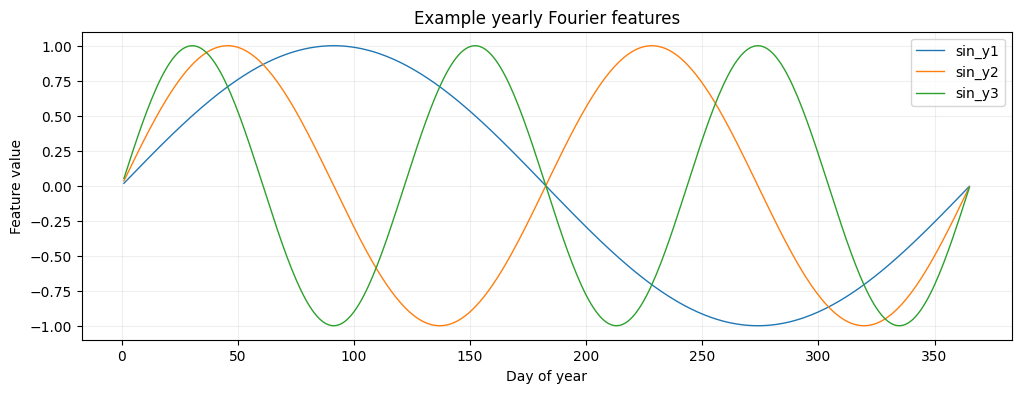

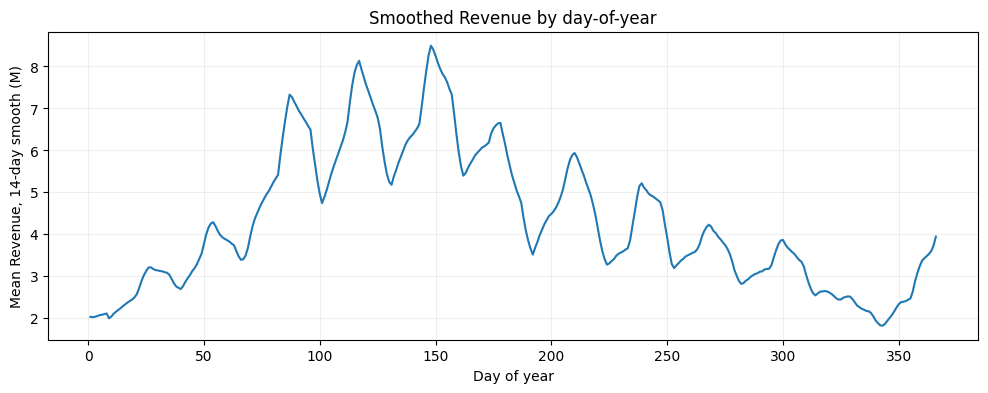

In [15]:
# Visualize why Fourier features are smooth cyclic encodings.
TAU = 2*np.pi
x = np.arange(1, 366)
plt.figure(figsize=(12,4))
for k in [1, 2, 3]:
    plt.plot(x, np.sin(TAU*k*x/365.25), label=f'sin_y{k}', lw=1)
plt.title('Example yearly Fourier features')
plt.xlabel('Day of year')
plt.ylabel('Feature value')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

# Compare smoothed day-of-year revenue with Fourier intuition.
doy_profile = sales.groupby('doy', as_index=False).Revenue.mean()
doy_profile['rev_smooth_14'] = doy_profile['Revenue'].rolling(14, center=True, min_periods=1).mean()
plt.figure(figsize=(12,4))
plt.plot(doy_profile['doy'], doy_profile['rev_smooth_14']/1e6)
plt.title('Smoothed Revenue by day-of-year')
plt.xlabel('Day of year')
plt.ylabel('Mean Revenue, 14-day smooth (M)')
plt.grid(alpha=0.2)
plt.show()


**Report note:** Fourier không tạo insight business mới, nhưng giúp model học seasonality liên tục: ngày 365 và ngày 1 gần nhau trong chu kỳ, điều mà one-hot `month/day` không biểu diễn mượt.


### 3.6 Fixed holidays / sale days → `hol_*`


,holiday,n_holiday_days,holiday_rev_mean,nearby_baseline_rev_mean,uplift_%,holiday_cogs_mean
0,new_year,10,3.833447e+06,1.767661e+06,116.865568,3.569110e+06
3,labor_day,10,1.004841e+07,5.110175e+06,96.635380,8.041184e+06
2,reunification,10,1.072114e+07,8.299887e+06,29.172149,8.581381e+06
7,dd_1212,11,2.303219e+06,2.054184e+06,12.123310,2.211110e+06
6,dd_1111,11,2.713134e+06,2.590125e+06,4.749173,2.172991e+06
5,vn_womens_day,11,3.236706e+06,3.192886e+06,1.372407,2.599121e+06
1,womens_day,10,3.516429e+06,3.531774e+06,-0.434483,2.823294e+06
4,national_day,11,2.951772e+06,3.452786e+06,-14.510438,3.014946e+06
9,christmas,11,2.369127e+06,3.332872e+06,-28.916350,2.231994e+06
8,christmas_eve,11,2.022062e+06,3.292736e+06,-38.590213,1.926594e+06


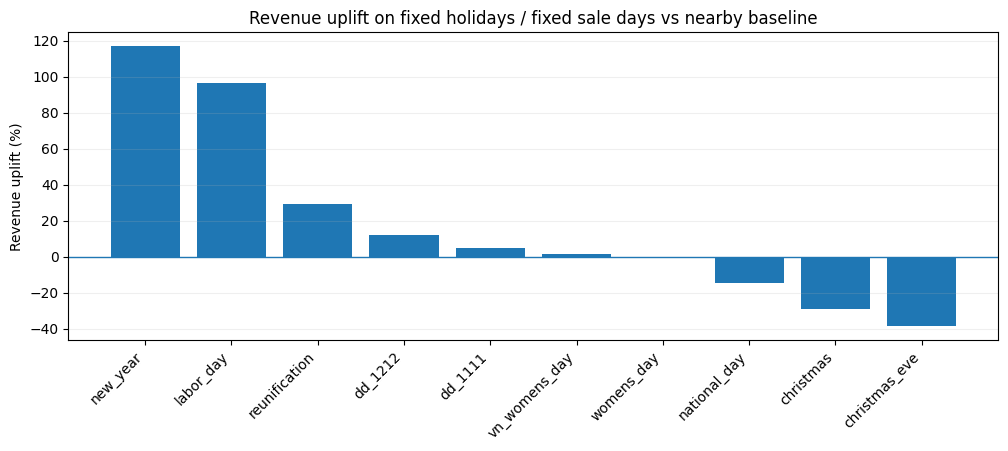

In [16]:
VN_FIXED_HOLIDAYS = [
    (1,1,'new_year'), (3,8,'womens_day'), (4,30,'reunification'),
    (5,1,'labor_day'), (9,2,'national_day'), (10,20,'vn_womens_day'),
    (11,11,'dd_1111'), (12,12,'dd_1212'),
    (12,24,'christmas_eve'), (12,25,'christmas'),
]

holiday_rows = []
for m, dd, name in VN_FIXED_HOLIDAYS:
    mask = (sales['month'].eq(m) & sales['day'].eq(dd))
    # baseline = +-7 days around same month/day excluding the holiday itself, across all years
    base_mask = (sales['month'].eq(m) & sales['day'].between(max(1, dd-7), min(31, dd+7)) & ~mask)
    if mask.sum() == 0 or base_mask.sum() == 0:
        continue
    holiday_rows.append({
        'holiday': name,
        'n_holiday_days': int(mask.sum()),
        'holiday_rev_mean': sales.loc[mask, 'Revenue'].mean(),
        'nearby_baseline_rev_mean': sales.loc[base_mask, 'Revenue'].mean(),
        'uplift_%': 100*(sales.loc[mask,'Revenue'].mean()/sales.loc[base_mask,'Revenue'].mean()-1),
        'holiday_cogs_mean': sales.loc[mask, 'COGS'].mean(),
    })

holiday_df = pd.DataFrame(holiday_rows).sort_values('uplift_%', ascending=False)
display(holiday_df)

plt.figure(figsize=(12,4))
plt.bar(holiday_df['holiday'], holiday_df['uplift_%'])
plt.axhline(0, lw=1)
plt.title('Revenue uplift on fixed holidays / fixed sale days vs nearby baseline')
plt.ylabel('Revenue uplift (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.2)
plt.show()


**Report note:** Với ngày lễ cố định, binary flag `hol_*` giúp model bắt demand spike/drop cụ thể. Cách so sánh tốt nhất là holiday mean so với nearby baseline cùng tháng, tránh nhầm với monthly seasonality.


### 3.7 Tết âm lịch → distance-to-Tet features

Tết không cố định theo dương lịch, nên dùng `month/day` không đủ. Feature đúng hơn là khoảng cách tới Tết.


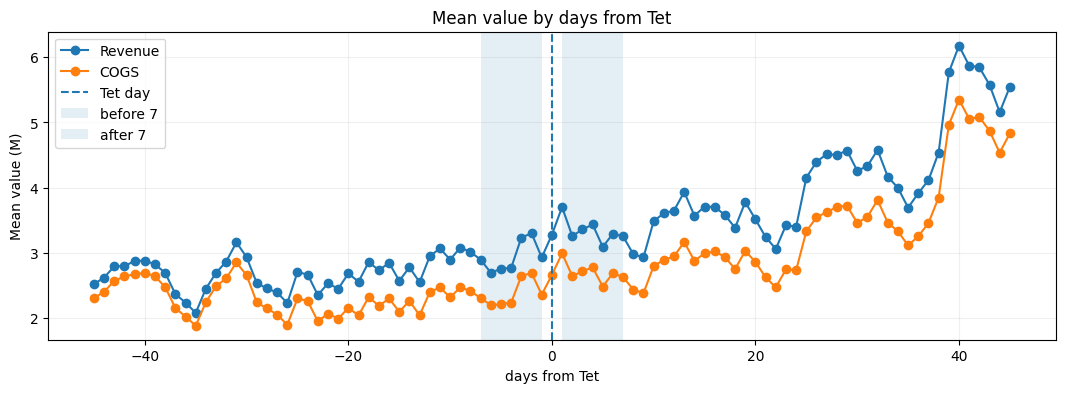

,Revenue,COGS,cost_ratio
tet_days_diff,,,
-45:-15,2.626357e+06,2.306651e+06,0.873322
-14:-8,2.907292e+06,2.342224e+06,0.804428
-7:-1,2.942291e+06,2.380622e+06,0.808003
Tet,3.280043e+06,2.663654e+06,0.811373
1:7,3.343580e+06,2.706493e+06,0.808561
8:14,3.452991e+06,2.787917e+06,0.808179
15:45,4.338719e+06,3.616758e+06,0.825912


In [17]:
TET_DATES = {
    2013:'2013-02-10', 2014:'2014-01-31', 2015:'2015-02-19',
    2016:'2016-02-08', 2017:'2017-01-28', 2018:'2018-02-16',
    2019:'2019-02-05', 2020:'2020-01-25', 2021:'2021-02-12',
    2022:'2022-02-01', 2023:'2023-01-22', 2024:'2024-02-10',
}

tet_lut = {y: pd.Timestamp(v) for y, v in TET_DATES.items()}
def nearest_tet_diff(dd):
    cands = [tet_lut.get(dd.year), tet_lut.get(dd.year-1), tet_lut.get(dd.year+1)]
    cands = [c for c in cands if c is not None]
    valid = [(dd-c).days for c in cands if abs((dd-c).days) <= 45]
    return min(valid, key=abs) if valid else np.nan

sales['tet_days_diff'] = sales['Date'].apply(nearest_tet_diff)
tet_win = sales[sales['tet_days_diff'].notna()].copy()
tet_profile = tet_win.groupby('tet_days_diff', as_index=False).agg(
    Revenue=('Revenue','mean'), COGS=('COGS','mean'), n=('Date','count')
)

plt.figure(figsize=(13,4))
plt.plot(tet_profile['tet_days_diff'], tet_profile['Revenue']/1e6, marker='o', label='Revenue')
plt.plot(tet_profile['tet_days_diff'], tet_profile['COGS']/1e6, marker='o', label='COGS')
plt.axvline(0, ls='--', label='Tet day')
plt.axvspan(-7, -1, alpha=0.12, label='before 7')
plt.axvspan(1, 7, alpha=0.12, label='after 7')
plt.title('Mean value by days from Tet')
plt.xlabel('days from Tet')
plt.ylabel('Mean value (M)')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

tet_bucket = pd.cut(tet_win['tet_days_diff'], [-46,-15,-8,-1,0,7,14,45], labels=['-45:-15','-14:-8','-7:-1','Tet','1:7','8:14','15:45'])
display(tet_win.groupby(tet_bucket)[['Revenue','COGS','cost_ratio']].mean())


**Report note:** `tet_days_diff`, `tet_before_7`, `tet_after_7`, `tet_in_14` tốt hơn fixed holiday vì ngày Tết đổi theo năm. Model có thể học pre-Tet demand và post-Tet drop/recovery.


### 3.8 Promo windows → `promo_*`, `since/until`, `disc`


,promo,n_days,promo_rev_mean,non_promo_rev_mean,rev_lift_%,promo_cogs_mean,promo_cost_ratio
0,spring_sale,310,5.968454e+06,4.138591e+06,44.214630,5.346654e+06,0.894644
1,mid_year,319,4.843688e+06,4.236010e+06,14.345517,4.553715e+06,0.942225
2,fall_launch,363,4.065677e+06,4.309693e+06,-5.662032,3.649964e+06,0.898651
4,urban_blowout,170,3.560603e+06,4.320277e+06,-17.583917,4.608336e+06,1.338706
5,rural_special,155,3.523465e+06,4.318744e+06,-18.414594,2.882108e+06,0.817528
3,year_end,504,2.538312e+06,4.551267e+06,-44.228452,2.434429e+06,0.966667


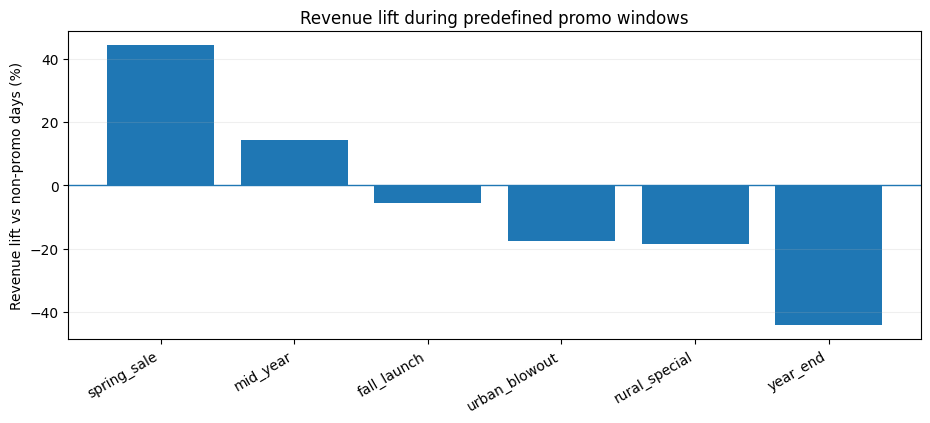

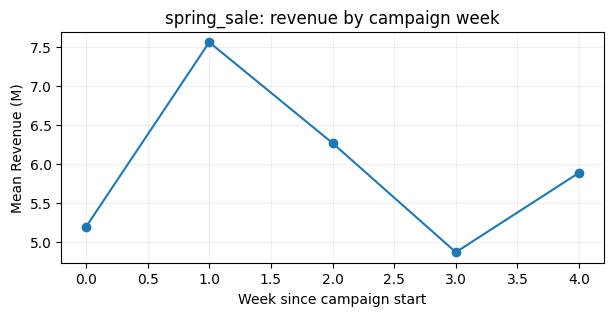

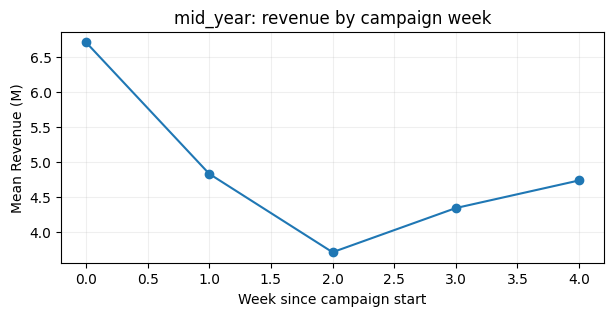

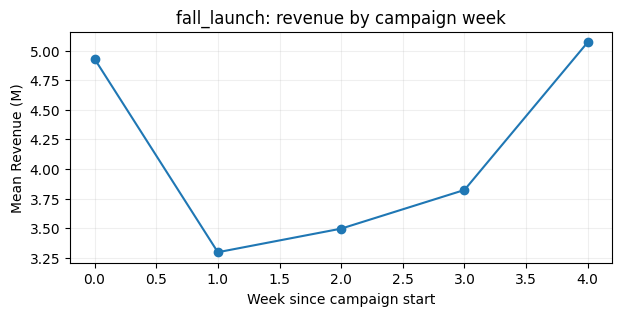

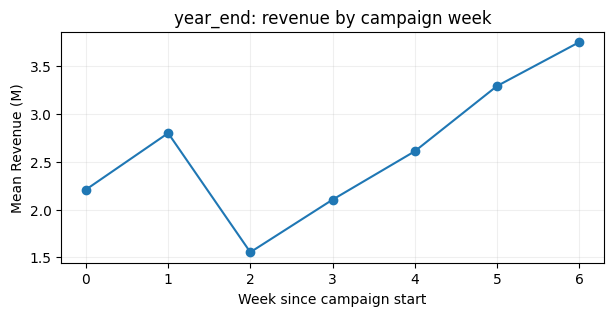

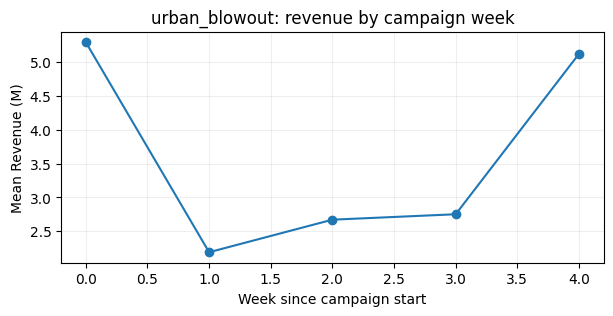

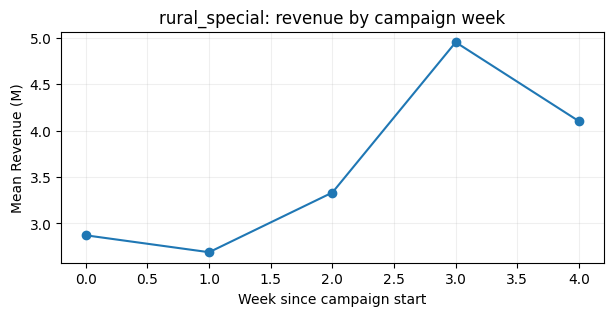

In [18]:
PROMO_SCHEDULE = [
    ('spring_sale',   3, 18, 30, 12, True),
    ('mid_year',      6, 23, 29, 18, True),
    ('fall_launch',   8, 30, 32, 10, True),
    ('year_end',     11, 18, 45, 20, True),
    ('urban_blowout', 7, 30, 33, None, 'odd'),
    ('rural_special', 1, 30, 30, 15,   'odd'),
]

def add_promo_flags(df):
    out = df.copy()
    for name, sm, sd, dur, disc, recur in PROMO_SCHEDULE:
        in_prom = np.zeros(len(out), dtype=int)
        since = np.full(len(out), np.nan)
        until = np.full(len(out), np.nan)
        discount = np.zeros(len(out), dtype=float)
        for y in range(out['year'].min()-1, out['year'].max()+2):
            if recur == 'odd' and y % 2 == 0:
                continue
            start = pd.Timestamp(year=y, month=sm, day=sd)
            end = start + pd.Timedelta(days=dur)
            mask = out['Date'].between(start, end)
            in_prom[mask] = 1
            since[mask] = (out.loc[mask, 'Date'] - start).dt.days
            until[mask] = (end - out.loc[mask, 'Date']).dt.days
            discount[mask] = disc or 0
        out[f'promo_{name}'] = in_prom
        out[f'promo_{name}_since'] = since
        out[f'promo_{name}_until'] = until
        out[f'promo_{name}_disc'] = discount
    promo_cols = [c for c in out.columns if c.startswith('promo_') and not c.endswith(('_since','_until','_disc'))]
    out['promo_any'] = out[promo_cols].max(axis=1)
    return out

sales = add_promo_flags(sales)

promo_summary = []
for name, *_ in PROMO_SCHEDULE:
    flag = f'promo_{name}'
    promo_mask = sales[flag].eq(1)
    base_mask = sales[flag].eq(0)
    promo_summary.append({
        'promo': name,
        'n_days': int(promo_mask.sum()),
        'promo_rev_mean': sales.loc[promo_mask, 'Revenue'].mean(),
        'non_promo_rev_mean': sales.loc[base_mask, 'Revenue'].mean(),
        'rev_lift_%': 100*(sales.loc[promo_mask,'Revenue'].mean()/sales.loc[base_mask,'Revenue'].mean()-1),
        'promo_cogs_mean': sales.loc[promo_mask, 'COGS'].mean(),
        'promo_cost_ratio': sales.loc[promo_mask, 'cost_ratio'].mean(),
    })
promo_df = pd.DataFrame(promo_summary).sort_values('rev_lift_%', ascending=False)
display(promo_df)

plt.figure(figsize=(11,4))
plt.bar(promo_df['promo'], promo_df['rev_lift_%'])
plt.axhline(0, lw=1)
plt.title('Revenue lift during predefined promo windows')
plt.ylabel('Revenue lift vs non-promo days (%)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.2)
plt.show()

# Effect within campaign age, useful for since/until features.
for name, *_ in PROMO_SCHEDULE:
    since_col = f'promo_{name}_since'
    if since_col not in sales.columns:
        continue
    d = sales[sales[f'promo_{name}'].eq(1)].copy()
    if len(d) == 0:
        continue
    d['campaign_week'] = (d[since_col] // 7).astype(int)
    prof = d.groupby('campaign_week', as_index=False).Revenue.mean()
    plt.figure(figsize=(7,3))
    plt.plot(prof['campaign_week'], prof['Revenue']/1e6, marker='o')
    plt.title(f'{name}: revenue by campaign week')
    plt.xlabel('Week since campaign start')
    plt.ylabel('Mean Revenue (M)')
    plt.grid(alpha=0.2)
    plt.show()


**Report note:** Promo flag chỉ nói ngày đó nằm trong campaign hay không; `since/until` giúp model biết campaign mới bắt đầu, giữa campaign, hay sắp kết thúc. `disc` cung cấp mức discount giả định của campaign.


### 3.9 August odd/even regime → nhóm feature tháng 8

Đây là insight targeted trong notebook model: `august_odd`, `august_even`, `august_last_week_even`, `august_odd_discount_regime`, và interaction với trend.


,parity,period,n,Revenue,COGS,cost_ratio
0,even_year,before_last_week,162,4.719349e+06,3.764034e+06,0.799481
1,even_year,last_week,24,1.027970e+07,8.274695e+06,0.806791
2,odd_year,before_last_week,135,2.885145e+06,3.888615e+06,1.368803
3,odd_year,last_week,20,5.685260e+06,7.473381e+06,1.327529


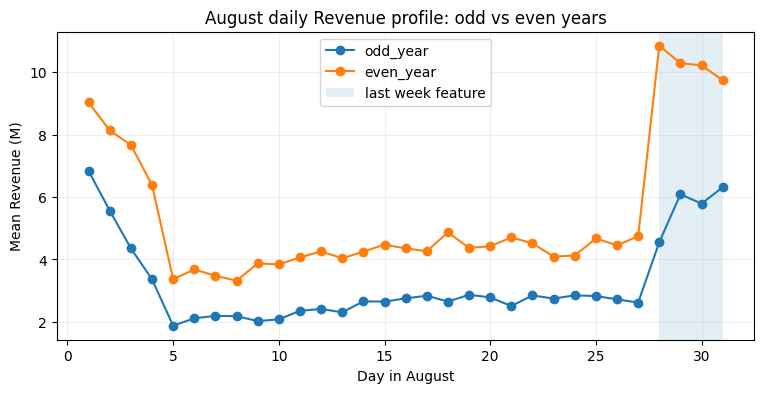

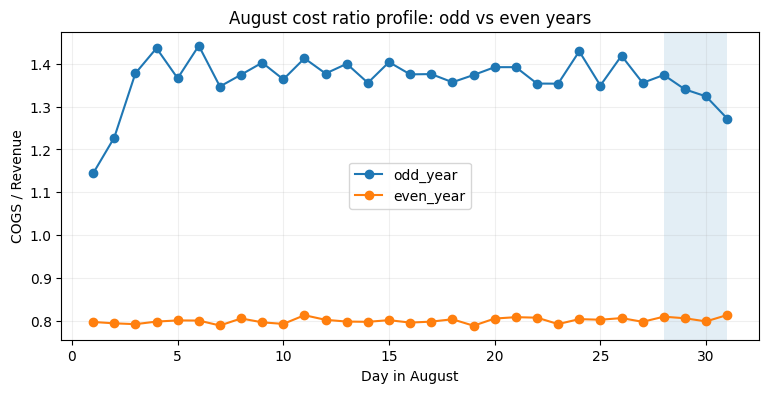

,parity,is_august,Revenue,COGS,cost_ratio,n
0,even_year,0,4.270648e+06,3.613032e+06,0.853351,1822
1,even_year,1,5.436813e+06,4.346055e+06,0.800424,186
2,odd_year,0,4.272401e+06,3.651323e+06,0.860686,1670
3,odd_year,1,3.246450e+06,4.351165e+06,1.363477,155


In [19]:
sales['is_odd_year'] = (sales['year'] % 2 == 1).astype(int)
sales['is_even_year'] = (sales['year'] % 2 == 0).astype(int)
sales['is_august'] = (sales['month'] == 8).astype(int)
sales['august_odd'] = sales['is_august'] * sales['is_odd_year']
sales['august_even'] = sales['is_august'] * sales['is_even_year']
sales['august_last_week'] = ((sales['month'] == 8) & (sales['day'] >= 28)).astype(int)
sales['august_last_week_even'] = sales['august_last_week'] * sales['is_even_year']
sales['august_last_week_odd'] = sales['august_last_week'] * sales['is_odd_year']

aug = sales[sales['month'].eq(8)].copy()
aug['parity'] = np.where(aug['year'] % 2 == 0, 'even_year', 'odd_year')
aug['period'] = np.where(aug['day'] >= 28, 'last_week', 'before_last_week')

aug_summary = aug.groupby(['parity','period'], as_index=False).agg(
    n=('Date','count'), Revenue=('Revenue','mean'), COGS=('COGS','mean'), cost_ratio=('cost_ratio','mean')
)
display(aug_summary)

plt.figure(figsize=(9,4))
for parity in ['odd_year', 'even_year']:
    d = aug[aug['parity'].eq(parity)].groupby('day', as_index=False).Revenue.mean()
    plt.plot(d['day'], d['Revenue']/1e6, marker='o', label=parity)
plt.axvspan(28, 31, alpha=0.12, label='last week feature')
plt.title('August daily Revenue profile: odd vs even years')
plt.xlabel('Day in August')
plt.ylabel('Mean Revenue (M)')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

plt.figure(figsize=(9,4))
for parity in ['odd_year', 'even_year']:
    d = aug[aug['parity'].eq(parity)].groupby('day', as_index=False).cost_ratio.mean()
    plt.plot(d['day'], d['cost_ratio'], marker='o', label=parity)
plt.axvspan(28, 31, alpha=0.12)
plt.title('August cost ratio profile: odd vs even years')
plt.xlabel('Day in August')
plt.ylabel('COGS / Revenue')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

# Compare August vs non-August within parity
parity_month = sales.assign(parity=np.where(sales['year']%2==0,'even_year','odd_year'))
comp = parity_month.groupby(['parity','is_august'], as_index=False).agg(
    Revenue=('Revenue','mean'), COGS=('COGS','mean'), cost_ratio=('cost_ratio','mean'), n=('Date','count')
)
display(comp)


## 4. Auxiliary-table evidence

Nguyên tắc: các bảng phụ như `web_traffic`, `orders`, `order_items`, `inventory` có thể không tồn tại cho tương lai. Vì vậy report nên nhấn mạnh: **không dùng raw future values**, chỉ dùng historical priors theo calendar bucket như `E[sessions | month]` hoặc `E[discount_ratio | month]`.


In [20]:
# =========================================================
# 4.1 Load auxiliary tables if available
# =========================================================
web = safe_read_csv('web_traffic.csv', parse_dates=['date'])
orders = safe_read_csv('orders.csv', parse_dates=['order_date'])
items = safe_read_csv('order_items.csv')
inv = safe_read_csv('inventory.csv', parse_dates=['snapshot_date'])
products = safe_read_csv('products.csv')


[OK] web_traffic.csv: (3652, 7)
[OK] orders.csv: (646945, 8)
[OK] order_items.csv: (714669, 7)
[OK] inventory.csv: (60247, 17)
[OK] products.csv: (2412, 8)


### 4.1 Web traffic priors → `exp_web_sessions_month`, `exp_web_*_month_dow`


,Revenue,COGS,web_sessions,web_unique_visitors,web_page_views
Revenue,1.000000,0.975994,0.321050,0.318787,0.301573
COGS,0.975994,1.000000,0.323547,0.320150,0.303177
web_sessions,0.321050,0.323547,1.000000,0.992026,0.919589
web_unique_visitors,0.318787,0.320150,0.992026,1.000000,0.911411
web_page_views,0.301573,0.303177,0.919589,0.911411,1.000000


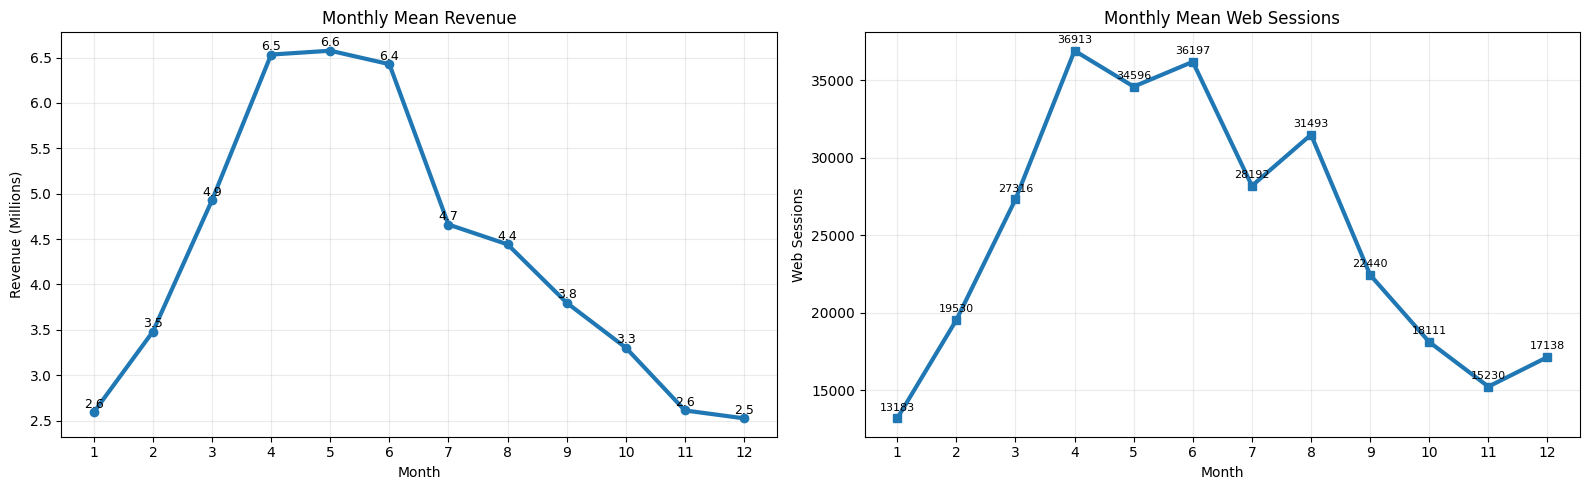

FEATURE ENGINEERING INSIGHT
Correlation between monthly Revenue and web sessions: 0.964

Observations:
- Revenue and web traffic follow similar monthly patterns.
- High traffic months align with high revenue months.
- Web sessions can be used as a proxy for demand intensity.

Potential features:
- web_sessions
- web_unique_visitors
- web_page_views
- web_sessions_month_mean
- traffic_spike_flag



In [27]:
if web is not None:
    web_daily = web.rename(columns={'date': 'Date'}).copy()
    web_daily['Date'] = pd.to_datetime(web_daily['Date'])

    web_daily = web_daily.groupby('Date', as_index=False).agg(
        web_sessions=('sessions', 'sum'),
        web_unique_visitors=('unique_visitors', 'sum'),
        web_page_views=('page_views', 'sum'),
        web_bounce_rate=('bounce_rate', 'mean'),
        web_avg_duration=('avg_session_duration_sec', 'mean'),
    )

    tmp = sales.copy()
    tmp['Date'] = pd.to_datetime(tmp['Date'])
    tmp['month'] = tmp['Date'].dt.month
    tmp['dow'] = tmp['Date'].dt.dayofweek

    tmp = tmp.merge(web_daily, on='Date', how='left')

    display(tmp[['Revenue', 'COGS', 'web_sessions',
                 'web_unique_visitors', 'web_page_views']].corr())

    m = tmp.groupby('month', as_index=False).agg(
        Revenue=('Revenue', 'mean'),
        web_sessions=('web_sessions', 'mean')
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(
        m['month'],
        m['Revenue'] / 1e6,
        marker='o',
        linewidth=3
    )
    axes[0].set_title('Monthly Mean Revenue')
    axes[0].set_xlabel('Month')
    axes[0].set_ylabel('Revenue (Millions)')
    axes[0].set_xticks(range(1, 13))
    axes[0].grid(alpha=0.25)

    for _, row in m.iterrows():
        axes[0].text(
            row['month'],
            row['Revenue'] / 1e6 + 0.05,
            f"{row['Revenue'] / 1e6:.1f}",
            ha='center',
            fontsize=9
        )

    axes[1].plot(
        m['month'],
        m['web_sessions'],
        marker='s',
        linewidth=3
    )
    axes[1].set_title('Monthly Mean Web Sessions')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Web Sessions')
    axes[1].set_xticks(range(1, 13))
    axes[1].grid(alpha=0.25)

    for _, row in m.iterrows():
        axes[1].text(
            row['month'],
            row['web_sessions'] + 500,
            f"{int(row['web_sessions'])}",
            ha='center',
            fontsize=8
        )

    plt.tight_layout()
    plt.show()

    corr = m['Revenue'].corr(m['web_sessions'])

    print("=" * 60)
    print("FEATURE ENGINEERING INSIGHT")
    print("=" * 60)
    print(f"Correlation between monthly Revenue and web sessions: {corr:.3f}")

    print("""
Observations:
- Revenue and web traffic follow similar monthly patterns.
- High traffic months align with high revenue months.
- Web sessions can be used as a proxy for demand intensity.

Potential features:
- web_sessions
- web_unique_visitors
- web_page_views
- web_sessions_month_mean
- traffic_spike_flag
""")

else:
    print('Skip: web_traffic.csv not found')

**Report note:** Web traffic là demand proxy. Vì không biết traffic tương lai, model dùng expected traffic theo tháng / tháng×weekday làm prior, sau đó tạo interaction với `weekend`, `first3`, `last3`, `august_even`.


### 4.2 Discount / unit price priors → `exp_aux_discount_*`, `exp_aux_avg_unit_price_*`, `exp_aux_units_sold_*`


,Revenue,COGS,cost_ratio,aux_discount_ratio,aux_discount_amount,aux_units_sold,aux_avg_unit_price,aux_order_lines
Revenue,1.000000,0.975994,-0.161404,-0.133344,0.232000,0.917849,-0.093996,0.915870
COGS,0.975994,1.000000,0.026527,-0.035530,0.345797,0.943355,-0.187619,0.941711
cost_ratio,-0.161404,0.026527,1.000000,0.448156,0.332229,0.035126,-0.487048,0.035993
aux_discount_ratio,-0.133344,-0.035530,0.448156,1.000000,0.772972,0.039561,-0.454047,0.040626
aux_discount_amount,0.232000,0.345797,0.332229,0.772972,1.000000,0.384998,-0.373928,0.385238
aux_units_sold,0.917849,0.943355,0.035126,0.039561,0.384998,1.000000,-0.407697,0.998438
aux_avg_unit_price,-0.093996,-0.187619,-0.487048,-0.454047,-0.373928,-0.407697,1.000000,-0.408151
aux_order_lines,0.915870,0.941711,0.035993,0.040626,0.385238,0.998438,-0.408151,1.000000


,month,Revenue,discount_ratio,unit_price,units
0,1,2.591155e+06,0.005963,5771.225655,485.325806
1,2,3.480801e+06,0.025376,5932.824027,620.762411
2,3,4.928185e+06,0.042014,5781.605833,915.774194
3,4,6.532952e+06,0.053914,5638.907584,1213.110000
4,5,6.575416e+06,0.000000,5962.828545,1161.625806
5,6,6.427109e+06,0.030438,5856.284764,1173.490000
6,7,4.659789e+06,0.089987,5438.356998,902.547337
7,8,4.441193e+06,0.004403,4952.025876,946.035191
8,9,3.797826e+06,0.078884,5589.401722,731.393939
9,10,3.302725e+06,0.002508,6091.054272,579.815249


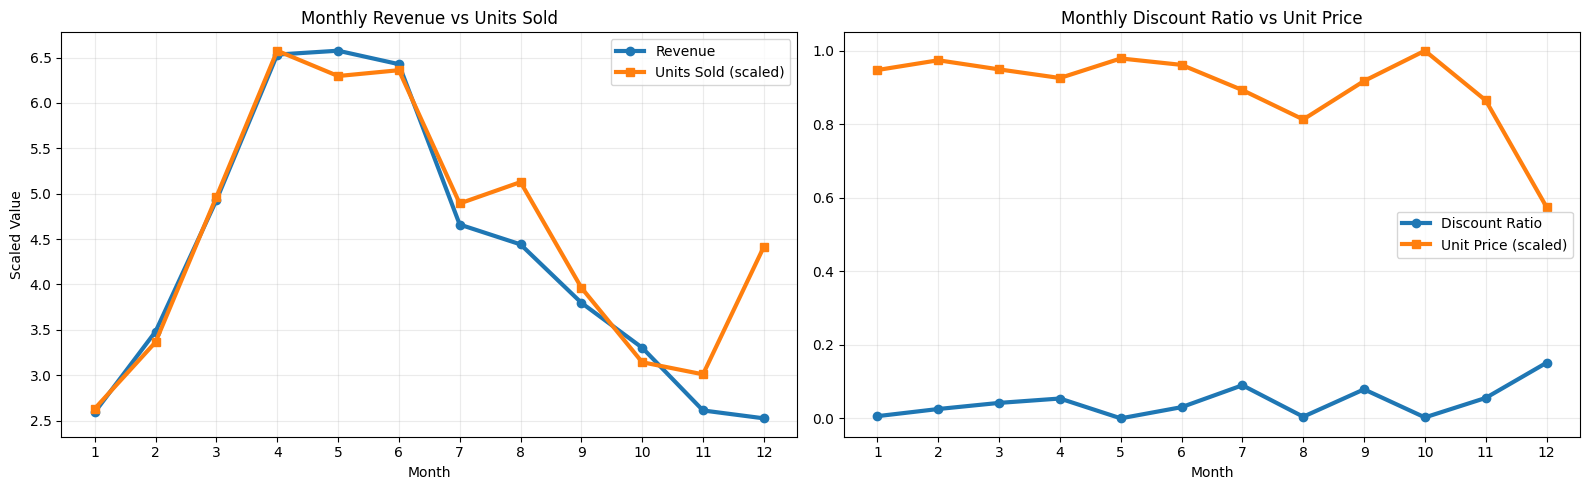

FEATURE ENGINEERING INSIGHT
Revenue vs Units correlation: 0.926
Revenue vs Discount correlation: -0.267

Observations:
- Revenue strongly follows units sold seasonality.
- Discount behavior changes across months.
- Some periods show higher discounting but weaker revenue uplift.

Potential feature engineering:
- aux_units_sold
- aux_discount_ratio
- aux_avg_unit_price
- promo_activity_rate
- seasonal_discount_pattern
- high_discount_month_flag

Business interpretation:
Sales volume and promotion intensity strongly affect revenue dynamics.



In [29]:
if orders is not None and items is not None:

    oi = items.merge(
        orders[['order_id', 'order_date']].rename(columns={'order_date': 'Date'}),
        on='order_id',
        how='left'
    )

    oi = oi.dropna(subset=['Date']).copy()
    oi['Date'] = pd.to_datetime(oi['Date'])

    oi['month'] = oi['Date'].dt.month
    oi['year'] = oi['Date'].dt.year
    oi['dow'] = oi['Date'].dt.dayofweek

    oi['line_net_value'] = oi['quantity'] * oi['unit_price']

    oi['line_discount'] = (
        oi['discount_amount'].fillna(0.0)
        if 'discount_amount' in oi.columns
        else 0.0
    )

    oi['line_gross_proxy'] = oi['line_net_value'] + oi['line_discount']

    oi['line_discount_ratio'] = (
        oi['line_discount'] /
        oi['line_gross_proxy'].replace(0, np.nan)
    ).fillna(0.0)

    if 'promo_id' in oi.columns:
        promo_1 = oi['promo_id'].notna()
    else:
        promo_1 = False

    if 'promo_id_2' in oi.columns:
        promo_2 = oi['promo_id_2'].notna()
    else:
        promo_2 = False

    oi['has_promo_line'] = (promo_1 | promo_2).astype(int)

    # =====================================================
    # DAILY AGG FEATURES
    # =====================================================

    promo_daily = oi.groupby('Date', as_index=False).agg(
        aux_discount_ratio=('line_discount_ratio', 'mean'),
        aux_discount_amount=('line_discount', 'sum'),
        aux_promo_line_rate=('has_promo_line', 'mean'),
        aux_units_sold=('quantity', 'sum'),
        aux_avg_unit_price=('unit_price', 'mean'),
        aux_order_lines=('order_id', 'count'),
    )

    tmp = sales.copy()
    tmp['Date'] = pd.to_datetime(tmp['Date'])
    tmp['month'] = tmp['Date'].dt.month
    tmp['dow'] = tmp['Date'].dt.dayofweek

    tmp = tmp.merge(promo_daily, on='Date', how='left')

    # =====================================================
    # CORRELATION
    # =====================================================

    display(
        tmp[
            [
                'Revenue',
                'COGS',
                'cost_ratio',
                'aux_discount_ratio',
                'aux_discount_amount',
                'aux_units_sold',
                'aux_avg_unit_price',
                'aux_order_lines'
            ]
        ].corr()
    )

    # =====================================================
    # MONTHLY PATTERNS
    # =====================================================

    m = tmp.groupby('month', as_index=False).agg(
        Revenue=('Revenue', 'mean'),
        discount_ratio=('aux_discount_ratio', 'mean'),
        unit_price=('aux_avg_unit_price', 'mean'),
        units=('aux_units_sold', 'mean')
    )

    display(m)

    # =====================================================
    # REVENUE vs UNITS SOLD
    # =====================================================

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(
        m['month'],
        m['Revenue'] / 1e6,
        marker='o',
        linewidth=3,
        label='Revenue'
    )

    scaled_units = (
        m['units'] / m['units'].max()
    ) * (m['Revenue'] / 1e6).max()

    axes[0].plot(
        m['month'],
        scaled_units,
        marker='s',
        linewidth=3,
        label='Units Sold (scaled)'
    )

    axes[0].set_title('Monthly Revenue vs Units Sold')
    axes[0].set_xlabel('Month')
    axes[0].set_ylabel('Scaled Value')
    axes[0].set_xticks(range(1, 13))
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    # =====================================================
    # DISCOUNT vs UNIT PRICE
    # =====================================================

    axes[1].plot(
        m['month'],
        m['discount_ratio'],
        marker='o',
        linewidth=3,
        label='Discount Ratio'
    )

    scaled_price = m['unit_price'] / m['unit_price'].max()

    axes[1].plot(
        m['month'],
        scaled_price,
        marker='s',
        linewidth=3,
        label='Unit Price (scaled)'
    )

    axes[1].set_title('Monthly Discount Ratio vs Unit Price')
    axes[1].set_xlabel('Month')
    axes[1].set_xticks(range(1, 13))
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # =====================================================
    # REPORT INSIGHT
    # =====================================================

    print("=" * 60)
    print("FEATURE ENGINEERING INSIGHT")
    print("=" * 60)

    corr_units = m['Revenue'].corr(m['units'])
    corr_discount = m['Revenue'].corr(m['discount_ratio'])

    print(f"Revenue vs Units correlation: {corr_units:.3f}")
    print(f"Revenue vs Discount correlation: {corr_discount:.3f}")

    print("""
Observations:
- Revenue strongly follows units sold seasonality.
- Discount behavior changes across months.
- Some periods show higher discounting but weaker revenue uplift.

Potential feature engineering:
- aux_units_sold
- aux_discount_ratio
- aux_avg_unit_price
- promo_activity_rate
- seasonal_discount_pattern
- high_discount_month_flag

Business interpretation:
Sales volume and promotion intensity strongly affect revenue dynamics.
""")

else:
    print('Skip: orders.csv or order_items.csv not found')

**Report note:** Discount/unit price phù hợp hơn với margin/cost-ratio model, còn units/order_lines phù hợp hơn với Revenue scale. Đây là lý do notebook tách `cols_rev` và `cols_margin`.


### 4.3 Inventory priors → `aux_inv_sell_through_rate`, `aux_inv_days_of_supply`, `aux_inv_stockout_rate`, ...


,month,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,days_of_supply,fill_rate,stockout_days,units_sold,units_received
0,1,0.662592,0.839022,0.0,0.116081,1191.075300,0.964975,1.050738,9.530443,10.984779
1,2,0.667834,0.806437,0.0,0.131394,996.849442,0.963565,1.093059,11.342457,13.180863
2,3,0.668562,0.755280,0.0,0.155079,888.361312,0.961840,1.144801,15.066206,17.602153
3,4,0.686933,0.670141,0.0,0.190117,675.200386,0.956875,1.293766,21.127196,24.944991
4,5,0.681063,0.709009,0.0,0.176118,763.799629,0.959155,1.225327,19.742036,23.213211
5,6,0.680523,0.716548,0.0,0.173734,743.189984,0.960894,1.173199,20.551861,24.205463
6,7,0.672203,0.752768,0.0,0.159529,817.333868,0.964184,1.074456,16.919244,19.835433
7,8,0.670637,0.710702,0.0,0.172969,703.438170,0.959990,1.200325,17.951272,21.109908
8,9,0.662757,0.786387,0.0,0.144064,967.504095,0.961821,1.145357,12.816766,14.923092
9,10,0.666472,0.811306,0.0,0.134587,1078.276823,0.962099,1.137037,11.298830,13.057505


,Revenue,COGS,cost_ratio
Revenue,1.000000,0.983011,-0.167776
COGS,0.983011,1.000000,0.009726
sell_through_rate,0.911774,0.960651,0.215516
units_sold,0.864980,0.913772,0.247285
units_received,0.864504,0.913530,0.248585
stockout_days,0.548639,0.579579,0.256252
stockout_flag,0.503414,0.489459,-0.016808
cost_ratio,-0.167776,0.009726,1.000000
month,-0.342181,-0.269310,0.501572
fill_rate,-0.548615,-0.579536,-0.256171


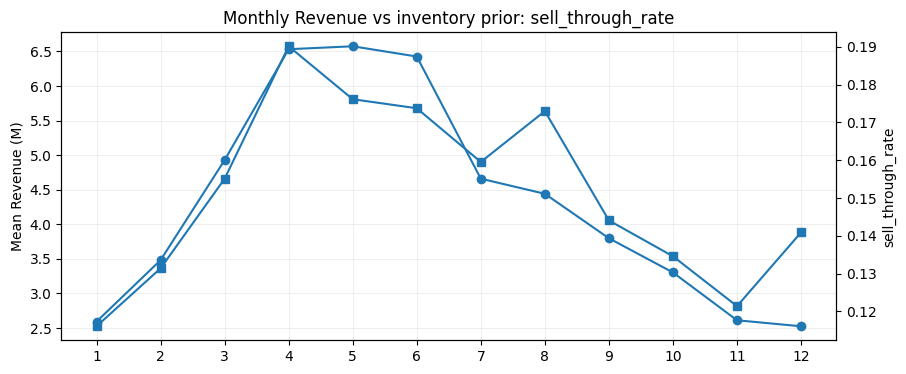

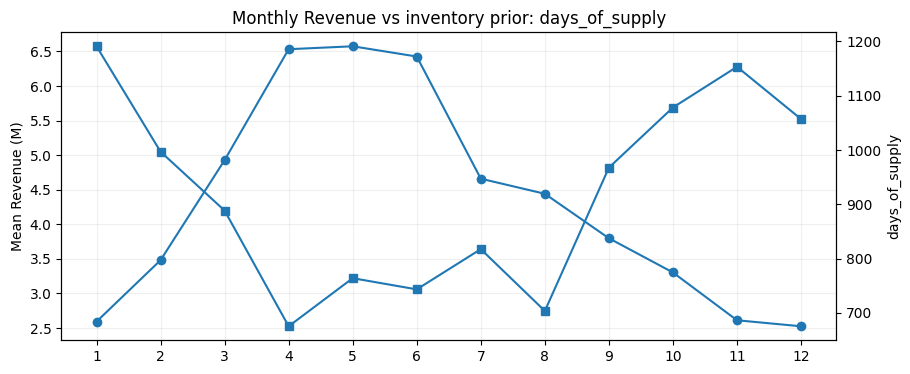

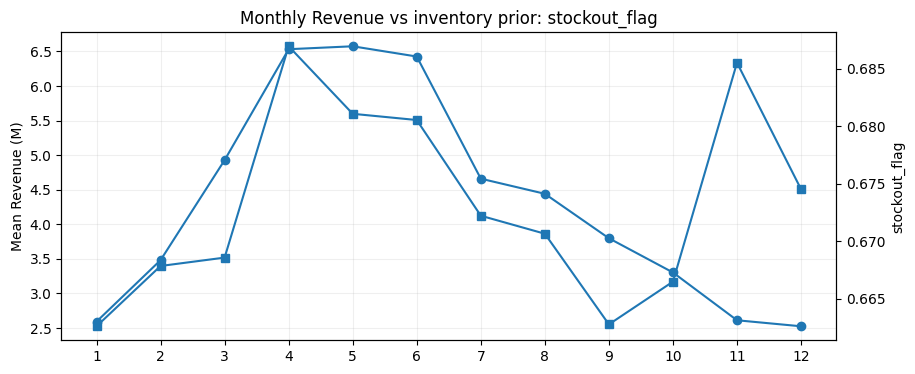

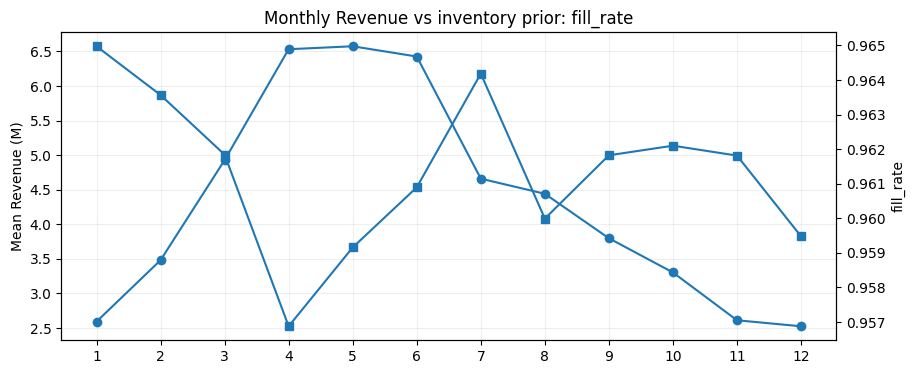

In [30]:
if inv is not None:
    inv2 = inv.copy()
    inv2['month'] = inv2['snapshot_date'].dt.month
    agg_cols = [c for c in ['stockout_flag','overstock_flag','reorder_flag','sell_through_rate','days_of_supply','fill_rate','stockout_days','units_sold','units_received'] if c in inv2.columns]
    inv_month = inv2.groupby('month', as_index=False)[agg_cols].mean()
    display(inv_month)

    # Merge monthly inventory prior into monthly sales summary for visual check.
    m_sales = sales.groupby('month', as_index=False).agg(Revenue=('Revenue','mean'), COGS=('COGS','mean'), cost_ratio=('cost_ratio','mean'))
    m = m_sales.merge(inv_month, on='month', how='left')
    display(m.corr(numeric_only=True)[['Revenue','COGS','cost_ratio']].sort_values('Revenue', ascending=False))

    for col in ['sell_through_rate','days_of_supply','stockout_flag','fill_rate']:
        if col not in m.columns:
            continue
        fig, ax1 = plt.subplots(figsize=(10,4))
        ax1.plot(m['month'], m['Revenue']/1e6, marker='o', label='Revenue')
        ax1.set_ylabel('Mean Revenue (M)')
        ax2 = ax1.twinx()
        ax2.plot(m['month'], m[col], marker='s', label=col)
        ax2.set_ylabel(col)
        ax1.set_xticks(range(1,13))
        ax1.set_title(f'Monthly Revenue vs inventory prior: {col}')
        ax1.grid(alpha=0.2)
        plt.show()
else:
    print('Skip: inventory.csv not found')


**Report note:** Inventory features là supply-side prior. Chúng không nhất thiết tăng Revenue trực tiếp trong mọi tháng, nhưng giúp giải thích capacity/stock pressure, đặc biệt khi interaction với `post2019`, `august`, `last3`.


### 4.4 Interaction features → khi business prior chỉ có ý nghĩa trong context cụ thể


In [31]:
# This cell demonstrates interaction logic, using available derived columns when possible.
interaction_examples = []

# sales already has first/last3 and august flags. Merge priors if they exist.
inter = sales.copy()
if 'promo_daily' in globals():
    inter = inter.merge(promo_daily[['Date','aux_discount_ratio','aux_units_sold']], on='Date', how='left')
if 'web_daily' in globals():
    inter = inter.merge(web_daily[['Date','web_sessions']], on='Date', how='left')

if 'web_sessions' in inter.columns:
    inter['sessions_bucket'] = pd.qcut(inter['web_sessions'], q=4, duplicates='drop')
    display(inter.groupby(['month_pos_bucket','sessions_bucket'], observed=True).Revenue.mean().unstack(0))

if 'aux_discount_ratio' in inter.columns:
    inter['discount_bucket'] = pd.qcut(inter['aux_discount_ratio'], q=4, duplicates='drop')
    display(inter.groupby(['is_august','discount_bucket'], observed=True)[['Revenue','cost_ratio']].mean())

# Explicit interaction feature names used in model.
interaction_feature_list = [
    'exp_discount_x_promo_any', 'exp_discount_x_post2019',
    'exp_discount_x_august_odd', 'exp_discount_x_august_even',
    'exp_promo_rate_x_post2019', 'exp_promo_rate_x_august',
    'exp_sessions_x_weekend', 'exp_sessions_x_first3', 'exp_sessions_x_last3', 'exp_sessions_x_august_even',
    'inv_sellthrough_x_post2019', 'inv_sellthrough_x_august',
    'inv_stockout_x_post2019', 'inv_stockout_x_last3',
    'exp_units_x_august_even', 'exp_units_x_month_end',
]
print('Interaction features used in model:')
for f in interaction_feature_list:
    print('-', f)


month_pos_bucket,first_3_days,last_3_days,middle_days
sessions_bucket,,,
"(7972.999, 17099.25]",2.954240e+06,4.990071e+06,2.915296e+06
"(17099.25, 23633.5]",3.142474e+06,5.186019e+06,3.179601e+06
"(23633.5, 31782.75]",6.764444e+06,8.962625e+06,4.789501e+06
"(31782.75, 50947.0]",7.543116e+06,8.470608e+06,4.609671e+06


Revenue  cost_ratio
is_august discount_bucket                           
0         (-0.001, 0.0909]  4.367785e+06    0.817080
          (0.0909, 0.167]   4.016766e+06    0.962078
1         (-0.001, 0.0909]  4.441193e+06    1.056357

Interaction features used in model:
- exp_discount_x_promo_any
- exp_discount_x_post2019
- exp_discount_x_august_odd
- exp_discount_x_august_even
- exp_promo_rate_x_post2019
- exp_promo_rate_x_august
- exp_sessions_x_weekend
- exp_sessions_x_first3
- exp_sessions_x_last3
- exp_sessions_x_august_even
- inv_sellthrough_x_post2019
- inv_sellthrough_x_august
- inv_stockout_x_post2019
- inv_stockout_x_last3
- exp_units_x_august_even
- exp_units_x_month_end


**Report note:** Interaction không phải thêm feature “cho nhiều”. Nó encode giả thuyết có điều kiện: traffic cao ở cuối tháng khác traffic cao ngày thường; discount trong August odd có ý nghĩa khác discount ở tháng bình thường; inventory pressure sau 2019 có thể khác trước 2019.


## 5. Final report-ready summary


In [26]:
report_summary = pd.DataFrame([
    ['Calendar + Fourier', 'Revenue, COGS', 'Bắt seasonal pattern theo tháng/tuần/năm mà không dùng recursive lag.'],
    ['Month boundary', 'Revenue', 'Bắt hiệu ứng đầu/cuối tháng: lương, campaign close, KPI, buying cycle.'],
    ['Trend/regime', 'Revenue, COGS, cost_ratio', 'Xử lý level shift 2019/Covid/post2022; tránh ép một seasonal pattern cho mọi năm.'],
    ['Fixed holidays + Tet', 'Revenue, COGS', 'Ngày lễ cố định và Tết âm lịch tạo local spikes/drops; Tết cần distance feature vì ngày thay đổi.'],
    ['Promo windows', 'Revenue, cost_ratio', 'Campaign kéo dài nhiều ngày; since/until/disc mô tả phase và intensity của promo.'],
    ['August odd/even', 'Revenue, cost_ratio', 'Tháng 8 có regime riêng theo parity; last-week even spike và odd discount-suppression.'],
    ['Web/order priors', 'Revenue', 'Traffic, units, order_lines là demand proxies; dùng historical expectation để tránh leakage.'],
    ['Discount/unit-price priors', 'cost_ratio / margin', 'Discount và price ảnh hưởng trực tiếp tới quan hệ COGS/Revenue hơn là traffic.'],
    ['Inventory priors', 'Revenue, COGS', 'Supply-side pressure: stockout, sell-through, days-of-supply, fill-rate.'],
    ['Interactions', 'Revenue, cost_ratio', 'Business signal chỉ mạnh trong context nhất định: first/last3, weekend, August, post2019.'],
], columns=['Feature group', 'Main target', 'Report explanation'])
display(report_summary)


,Feature group,Main target,Report explanation
0,Calendar + Fourier,"Revenue, COGS",Bắt seasonal pattern theo tháng/tuần/năm mà kh...
1,Month boundary,Revenue,"Bắt hiệu ứng đầu/cuối tháng: lương, campaign c..."
2,Trend/regime,"Revenue, COGS, cost_ratio",Xử lý level shift 2019/Covid/post2022; tránh é...
3,Fixed holidays + Tet,"Revenue, COGS",Ngày lễ cố định và Tết âm lịch tạo local spike...
4,Promo windows,"Revenue, cost_ratio",Campaign kéo dài nhiều ngày; since/until/disc ...
5,August odd/even,"Revenue, cost_ratio",Tháng 8 có regime riêng theo parity; last-week...
6,Web/order priors,Revenue,"Traffic, units, order_lines là demand proxies;..."
7,Discount/unit-price priors,cost_ratio / margin,Discount và price ảnh hưởng trực tiếp tới quan...
8,Inventory priors,"Revenue, COGS","Supply-side pressure: stockout, sell-through, ..."
9,Interactions,"Revenue, cost_ratio",Business signal chỉ mạnh trong context nhất đị...


### Đoạn markdown có thể paste vào report

Trong bài dự báo, em không chỉ sử dụng calendar feature cơ bản mà xây dựng feature theo các giả thuyết business có thể kiểm chứng bằng EDA. Cụ thể, doanh thu có tính mùa vụ theo tháng và thứ trong tuần nên em dùng `month`, `dow`, `is_weekend` và Fourier seasonality để biểu diễn chu kỳ mượt. Quan sát theo vị trí trong tháng cho thấy đầu/cuối tháng có mức doanh thu khác ngày giữa tháng, vì vậy em thêm `is_first1/2/3`, `is_last1/2/3`, `days_from_som`, `days_to_eom`. Series cũng có thay đổi level rõ quanh giai đoạn 2019/Covid và giai đoạn gần 2022, nên em thêm trend và regime features như `t_years`, `t_years2`, `regime_post2019`, `regime_post2022`.

Ngoài ra, các ngày lễ cố định, Tết âm lịch và campaign window được mã hoá riêng. Với Tết, do ngày thay đổi theo từng năm, em dùng khoảng cách tới Tết (`tet_days_diff`, `tet_before_7`, `tet_after_7`) thay vì chỉ dùng month/day. Với promotion, em không chỉ dùng flag trong campaign mà còn dùng `since`, `until`, và mức discount để mô tả phase của campaign. Một insight quan trọng từ EDA là tháng 8 có hành vi khác nhau giữa năm chẵn và năm lẻ, đặc biệt cuối tháng 8 ở năm chẵn có xu hướng spike, nên em thêm các interaction như `august_even`, `august_odd`, `august_last_week_even`.

Đối với các bảng phụ như web traffic, order items và inventory, em tránh dùng raw future values để không leakage. Thay vào đó, em tạo các historical priors theo calendar bucket như `E[sessions | month]`, `E[discount_ratio | month]`, `E[units_sold | month]`, và inventory prior theo tháng. Các prior này sau đó được interaction với context quan trọng như weekend, first/last 3 days, August và post-2019 regime. Cách này giúp model tận dụng thông tin business từ bảng phụ nhưng vẫn giữ bài toán forecast hợp lệ.
